In [17]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [18]:
training_cells = ["B0005","B0006","B0007","B0018"]
processed_fldr = "../data/processed/"
training_fldr = "../data/training/"
testing_fldr = "../data/testing/"

In [19]:
def degradation_class(soh):
    class_no = 0
    if soh >= 90:
        class_no = 0 # Healthy
    elif soh < 90 and soh >= 80:
        class_no = 1 # Advance Degradation
    else:
        class_no = 3 # Critical
    
    return class_no

In [20]:
# list of features
volt_start = []
volt_end = []
volt_std = []
temp_max = []
temp_min = []
temp_avg = []
temp_std = []
curr_max = []
curr_min = []
curr_avg = []
curr_std = []
time_to_0soc = []
time_to_10soc = []
time_to_25soc = []
time_to_40soc = []
time_to_50soc = []
degradation = []


In [ ]:
training_filename = "diagnostic_data"

In [22]:
file_count = 0
for fldr in os.listdir(processed_fldr):
    if fldr in training_cells:
        dchg_fldr = processed_fldr + fldr + "/discharge/"
        no_of_files = len(os.listdir(dchg_fldr))
        initial_capacity = 0
        print(f"folder {dchg_fldr} with no of files {no_of_files}")
        for i in range(0,no_of_files):
            file_count += 1
            file = f"dchgCycle_{i}.csv"
            filename = dchg_fldr + file
            df = pd.read_csv(filename)
            
            time = df["time"].values
            voltage = df["voltage"].values
            current = df["current"].values
            temperature = df["temperature"].values
            soc = df["soc"].values
            cap = df["capacity"].values[0]

            if i == 0:
                initial_capacity = cap
                soh = (cap/initial_capacity)*100
            else:
                soh = (cap/initial_capacity)*100

            volt_start.append(voltage[0])
            volt_end.append(voltage[-1])
            volt_std.append(np.std(voltage))
            temp_max.append(np.max(temperature))
            temp_min.append(np.min(temperature))
            temp_avg.append(np.average(temperature))
            temp_std.append(np.std(temperature))
            curr_max.append(np.min(current))    # discharge current is negative
            curr_min.append(np.max(current))    # discharge current is negative
            curr_avg.append(np.average(current))
            curr_std.append(np.std(current))
            degradation.append(degradation_class(soh))

            soc_time_fnc = interp1d(soc, time)

            time_to_0soc.append(soc_time_fnc(0))
            time_to_10soc.append(soc_time_fnc(0.1))
            time_to_25soc.append(soc_time_fnc(0.25))
            time_to_40soc.append(soc_time_fnc(0.4))
            time_to_50soc.append(soc_time_fnc(0.5))


diag_df = pd.DataFrame({
    "volt_start": volt_start, 
    "volt_end": volt_end, 
    "volt_std": volt_std, 
    "temp_max": temp_max, 
    "temp_min": temp_min,  
    "temp_avg": temp_avg, 
    "temp_std": temp_std, 
    "curr_max": curr_max, 
    "curr_min": curr_min, 
    "curr_avg": curr_avg, 
    "curr_std": curr_std, 
    "time_to_0soc": np.array(time_to_0soc).astype(np.float64), 
    "time_to_10soc": np.array(time_to_10soc).astype(np.float64), 
    "time_to_25soc": np.array(time_to_25soc).astype(np.float64), 
    "time_to_40soc": np.array(time_to_40soc).astype(np.float64), 
    "time_to_50soc": np.array(time_to_50soc).astype(np.float64),
    "degradation": degradation})   

diag_df.to_csv(training_fldr + training_filename + ".csv", index=False)  

print(file_count)

folder ../data/processed/B0005/discharge/ with no of files 168
folder ../data/processed/B0006/discharge/ with no of files 168
folder ../data/processed/B0007/discharge/ with no of files 168
folder ../data/processed/B0018/discharge/ with no of files 132
636


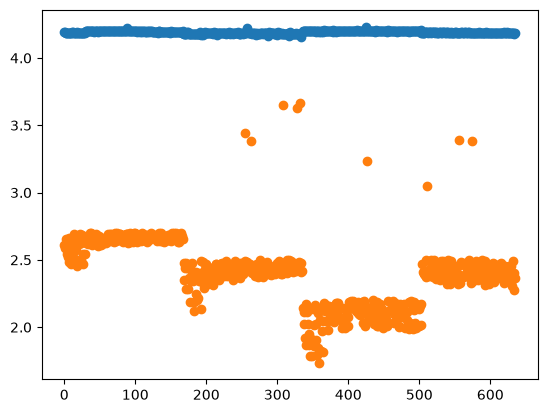

In [24]:
plt.scatter(range(len(volt_start)),volt_start)
plt.scatter(range(len(volt_end)),volt_end)

In [25]:
diag_df.head()

,volt_start,volt_end,volt_std,temp_max,temp_min,temp_avg,temp_std,curr_max,curr_min,curr_avg,curr_std,time_to_0soc,time_to_10soc,time_to_25soc,time_to_40soc,time_to_50soc,degradation
0,4.191492,2.612467,0.221937,38.904112,24.325993,32.196748,3.385642,-2.018015,-0.001478,-1.990294,0.210638,3346.937,2988.798734,2494.925688,1993.781164,1660.722284,0
1,4.189773,2.587209,0.220868,38.934590,24.685948,32.351774,3.323879,-2.016821,0.000021,-1.990079,0.211502,3328.828,2970.932149,2476.991823,1981.776433,1651.256208,0
2,4.188187,2.651917,0.215820,38.743649,24.734266,32.277595,3.283721,-2.016574,-0.001754,-1.989882,0.211939,3309.422,2955.190865,2462.807846,1970.217046,1642.873262,0
3,4.188461,2.592948,0.219867,38.672511,24.652244,32.151764,3.276088,-2.015936,0.000234,-1.989586,0.211961,3309.719,2953.807410,2462.541808,1969.481263,1641.440990,0
4,4.188299,2.547420,0.222766,38.558828,24.518700,32.014608,3.280730,-2.017426,0.001701,-1.990128,0.211820,3307.688,2955.855436,2462.511873,1968.414178,1640.533634,0


In [26]:
diag_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   volt_start     636 non-null    float64
 1   volt_end       636 non-null    float64
 2   volt_std       636 non-null    float64
 3   temp_max       636 non-null    float64
 4   temp_min       636 non-null    float64
 5   temp_avg       636 non-null    float64
 6   temp_std       636 non-null    float64
 7   curr_max       636 non-null    float64
 8   curr_min       636 non-null    float64
 9   curr_avg       636 non-null    float64
 10  curr_std       636 non-null    float64
 11  time_to_0soc   636 non-null    float64
 12  time_to_10soc  636 non-null    float64
 13  time_to_25soc  636 non-null    float64
 14  time_to_40soc  636 non-null    float64
 15  time_to_50soc  636 non-null    float64
 16  degradation    636 non-null    int64  
dtypes: float64(16), int64(1)
memory usage: 84.6 KB


In [27]:
diag_df.describe()

,volt_start,volt_end,volt_std,temp_max,temp_min,temp_avg,temp_std,curr_max,curr_min,curr_avg,curr_std,time_to_0soc,time_to_10soc,time_to_25soc,time_to_40soc,time_to_50soc,degradation
count,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000
mean,4.191760,2.402167,0.246103,39.449706,23.944609,31.905984,3.720085,-2.010235,0.000017,-1.987202,0.180228,2874.701706,2555.968347,2130.125997,1704.127055,1420.071807,1.556604
std,0.008604,0.252369,0.016558,1.429621,0.576096,0.868797,0.367070,0.009747,0.002056,0.023163,0.049962,361.935364,323.473912,269.562205,215.634520,179.659993,1.322704
min,4.157545,1.737030,0.210613,36.270543,22.350256,29.804108,3.092217,-2.029098,-0.006279,-2.001462,0.145865,2108.406000,1860.103448,1548.392307,1238.477830,1032.369606,0.000000
25%,4.185455,2.187984,0.233338,38.231167,23.566940,31.253386,3.402300,-2.016468,-0.001268,-1.996912,0.160467,2587.039250,2299.354217,1915.005421,1532.453466,1276.847233,0.000000
50%,4.190385,2.424784,0.247271,39.547779,23.976510,32.017988,3.691339,-2.014195,-0.000246,-1.992843,0.169964,2834.961000,2517.208708,2097.082553,1678.264833,1398.287670,1.000000
75%,4.199195,2.604183,0.257990,40.716761,24.313942,32.510865,3.996372,-2.000385,0.001141,-1.977993,0.188944,3188.730000,2845.631109,2371.215922,1897.350438,1580.728305,3.000000
max,4.233146,3.663027,0.281175,42.083729,26.647374,34.125027,4.768481,-1.992201,0.014306,-1.673230,0.749985,3690.234000,3279.369128,2733.002353,2184.464415,1821.691176,3.000000


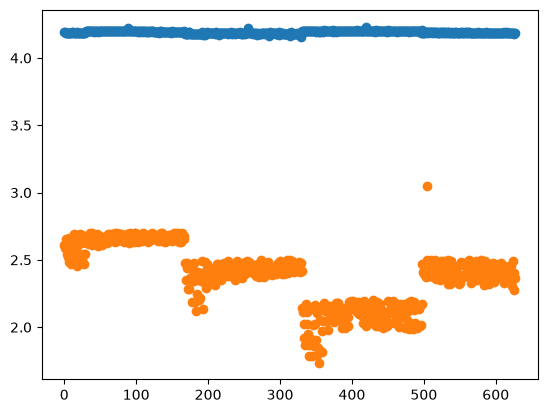

In [28]:
# Removing outlier based on volt_end

Q1 = diag_df['volt_end'].quantile(0.25)
Q3 = diag_df["volt_end"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

diag_df = diag_df[(diag_df['volt_end'] >= lower_limit) & (diag_df["volt_end"] <= upper_limit)]

diag_df.to_csv(training_fldr + training_filename + ".csv", index=False) 

plt.scatter(range(len(diag_df['volt_start'])),diag_df['volt_start'])
plt.scatter(range(len(diag_df['volt_end'])),diag_df['volt_end'])

# Spliting data into training and testing

- Training Data: Will be used for training and validation
- Testing Data: It will be used for final model validation

In [29]:
training_filename = "training_data"
testing_filename = "test_data"

In [30]:
from sklearn.model_selection import train_test_split

In [32]:
X = diag_df.drop('degradation', axis=1)
y = diag_df['degradation']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)

In [35]:
print(f"Training size: {X_train.shape}")
print(f"Testing size: {X_test.shape}")

Training size: (502, 16)
Testing size: (126, 16)


In [58]:
y.value_counts()

degradation
3    272
0    200
1    156
Name: count, dtype: int64

In [57]:
y_train.value_counts()

degradation
3    217
0    160
1    125
Name: count, dtype: int64

In [56]:
y_test.value_counts()

degradation
3    55
0    40
1    31
Name: count, dtype: int64

Text(0.5, 1.0, 'Training Data')

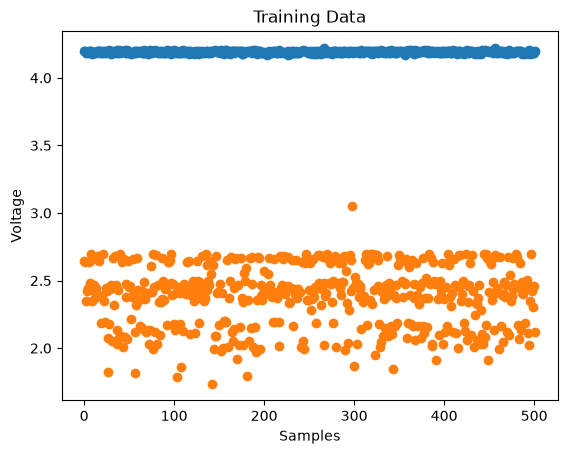

In [42]:
plt.scatter(range(len(X_train['volt_start'])),X_train['volt_start'])
plt.scatter(range(len(X_train['volt_end'])),X_train['volt_end'])
plt.xlabel("Samples")
plt.ylabel("Voltage")
plt.title("Training Data")

Text(0.5, 1.0, 'Testing Data')

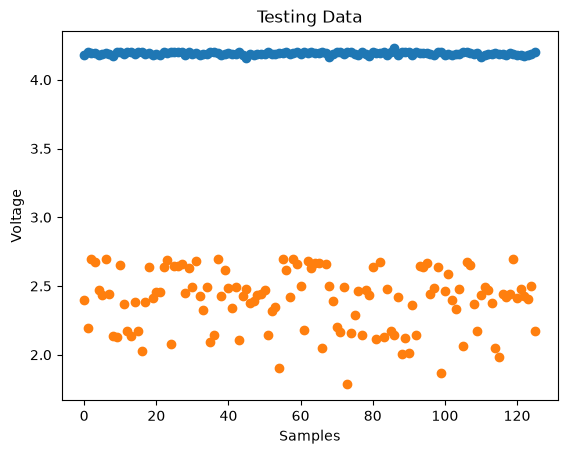

In [43]:
plt.scatter(range(len(X_test['volt_start'])),X_test['volt_start'])
plt.scatter(range(len(X_test['volt_end'])),X_test['volt_end'])
plt.xlabel("Samples")
plt.ylabel("Voltage")
plt.title("Testing Data")

In [50]:
training_data = pd.concat([X_train, pd.DataFrame(y_train)], axis=1)

In [51]:
training_data.head()

,volt_start,volt_end,volt_std,temp_max,temp_min,temp_avg,temp_std,curr_max,curr_min,curr_avg,curr_std,time_to_0soc,time_to_10soc,time_to_25soc,time_to_40soc,time_to_50soc,degradation
138,4.195824,2.642142,0.246931,41.310604,24.647812,33.126396,4.113589,-2.017618,0.002159,-1.996993,0.175478,2437.844,2181.681065,1817.606470,1453.745804,1211.754507,3
93,4.197874,2.633849,0.237909,40.144923,24.254987,32.437783,3.780822,-2.017976,0.001225,-1.998735,0.165397,2745.984,2456.109183,2049.623755,1638.749696,1365.041948,1
631,4.186190,2.347109,0.266719,38.614087,23.715085,31.202708,3.717289,-2.012842,-0.001443,-1.987252,0.208688,2485.594,2198.546420,1831.921667,1463.759769,1220.198728,3
522,4.187636,2.419990,0.224710,36.683919,23.127325,30.308940,3.181892,-2.012078,0.002707,-1.994629,0.162481,3156.406,2819.049320,2346.857867,1879.319545,1565.397759,0
226,4.184519,2.443724,0.241404,39.409750,24.442915,32.119068,3.598844,-2.017070,0.000834,-1.997728,0.158946,2970.203,2641.014418,2203.839130,1761.817871,1467.398906,1


In [52]:
testing_data = pd.concat([X_test, pd.DataFrame(y_test)], axis=1)

In [53]:
testing_data.head()

,volt_start,volt_end,volt_std,temp_max,temp_min,temp_avg,temp_std,curr_max,curr_min,curr_avg,curr_std,time_to_0soc,time_to_10soc,time_to_25soc,time_to_40soc,time_to_50soc,degradation
305,4.181109,2.395755,0.257210,40.734482,24.359100,32.831423,4.199375,-2.014080,-0.002785,-1.994653,0.177453,2371.031,2095.381835,1745.924271,1397.155416,1165.150423,3
404,4.202295,2.191482,0.248979,40.098301,23.784086,31.993089,3.710892,-1.993257,-0.001902,-1.977323,0.154452,3079.812,2735.736339,2276.316080,1821.342191,1519.297711,1
164,4.195624,2.696396,0.245738,40.857545,23.800266,32.505195,4.289915,-2.018933,-0.001811,-1.996589,0.179716,2318.109,2070.621381,1727.269878,1382.960430,1151.183762,3
137,4.195912,2.676480,0.244208,41.107728,24.392659,32.926184,4.134938,-2.016151,0.001019,-1.997020,0.175291,2437.719,2179.093979,1818.696034,1454.716676,1211.942436,3
277,4.182245,2.472237,0.250457,41.547094,24.833794,33.465561,4.249545,-2.015380,-0.001352,-1.995557,0.171887,2530.453,2247.381085,1872.335828,1498.558700,1248.177028,3


In [59]:
training_data.to_csv(training_fldr + training_filename + ".csv", index=False)
testing_data.to_csv(testing_fldr + testing_filename + ".csv", index=False)